# Tutorial: Preparing a ligand library for docking with Gypsum-DL

This notebook turns a **reference drug** into a small, **docking-ready 3D ligand library** — the
input consumed by the virtual-screening pipeline in
[`notebook_tutorial.ipynb`](notebook_tutorial.ipynb).

The seed is **Imatinib**, the drug co-crystallized in PDB
[`3HEC`](https://www.rcsb.org/structure/3HEC) with **p38α MAP kinase** and in [`8S16`](https://www.rcsb.org/structure/8S16) with **c-KIT kinase**. We fetch a handful of similar
molecules from **ChEMBL**, then walk through the cheminformatics needed
*before* docking:

1. **Fetch** analogs from ChEMBL
2. **Parse & sanitize** SMILES with RDKit
3. **Standardize** — desalt, neutralize, canonicalize
4. **Remove isotope duplicates**
5. **Fingerprint similarity** in RDKit
6. **Protonation** at physiological pH
7. **3D conformer generation**
8. **Production prep with Gypsum-DL** → write a docking-ready **SDF**

> Run this from the **repository root** in the `biobb_vs_ligprep` environment
> (`notebooks/ligand_prep.yml`).

In [30]:
import os, shutil, subprocess
from pathlib import Path

import pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.MolStandardize import rdMolStandardize

RDLogger.DisableLog("rdApp.info")  # quiet RDKit info; keep warnings/errors

# --- Configuration ---
REFERENCE_SMILES = "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"  # Imatinib
SIMILARITY_THRESHOLD = 80                       # % Tanimoto (ChEMBL expects an integer, 40-100)
N_LIGANDS = 10                                  # keep it a small teaching set
MAX_VARIANTS = 3                                # Maximum variants per ligand
MIN_PH, MAX_PH, PKA_PRECISION = 7.0, 8.0, 0.5   # physiological pH window for protonation
OUTPUT_SDF = "data/ligands/imatinib_analogs_prepared.sdf"
WORK_DIR = "ligand_prep_out"                    # scratch for the .smi and Gypsum-DL output

# Locate the repository root so data/ paths resolve, whether this notebook is launched
# from the repo root or from inside notebooks/.
for _ in range(3):
    if Path("data/ligands").is_dir():
        break
    os.chdir("..")
assert Path("data/ligands").is_dir(), "Could not find data/ligands/ - run from the repo root."
print("Working directory:", os.getcwd())
os.makedirs(WORK_DIR, exist_ok=True)
print("RDKit version:", Chem.rdBase.rdkitVersion)

Working directory: /shared/work/BiobbWorkflows/src/biobb_vs_workflows
RDKit version: 2025.09.6


## 1. Fetch analogs from ChEMBL

We ask [ChEMBL](https://www.ebi.ac.uk/chembl/) for molecules whose **2D Morgan-fingerprint Tanimoto
similarity** to Imatinib is ≥ 80 %. This is a fast, structure-only way to seed a focused library
around a known active.

The next cell falls back to a small **curated** analog set if ChEMBL is unreachable, so the notebook
always runs offline.

In [16]:
def fetch_from_chembl(reference_smiles, threshold, limit):
    """Return [(identifier, smiles), ...] analogs from ChEMBL, or raise on failure."""
    from chembl_webresource_client.new_client import new_client
    hits = new_client.similarity.filter(
        smiles=reference_smiles, similarity=threshold
    ).only(["molecule_chembl_id", "molecule_structures"])
    out = []
    for rec in hits[: limit * 4]:                       # over-fetch, then cap
        smi = (rec.get("molecule_structures") or {}).get("canonical_smiles")
        if smi:
            out.append((rec["molecule_chembl_id"], smi))
        if len(out) >= limit:
            break
    if not out:
        raise RuntimeError("ChEMBL returned no usable structures")
    return out

# Curated fallback: Imatinib + small, chemically-valid variations (offline-safe teaching set).
# Descriptive names are used (not real ChEMBL IDs) to be honest about their provenance.
FALLBACK = [
    ("imatinib",            REFERENCE_SMILES),
    ("NdesmethylImatinib",  "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCNCC5"),
    ("NethylAnalog",        "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)CC"),
    ("NhydroxyethylAnalog", "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)CCO"),
    ("phenylAnalog",        "Cc1ccc(cc1Nc2nccc(n2)c3ccccc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"),
    ("pyridin4ylAnalog",    "Cc1ccc(cc1Nc2nccc(n2)c3ccncc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C"),
]

print(f"Querying ChEMBL for Tanimoto >= {SIMILARITY_THRESHOLD}% to Imatinib ...")
try:
    analogs = fetch_from_chembl(REFERENCE_SMILES, SIMILARITY_THRESHOLD, N_LIGANDS)
    source = "ChEMBL"
except Exception as e:
    print(f"  ChEMBL unavailable ({type(e).__name__}: {str(e).splitlines()[0][:100]})")
    print("  -> using curated fallback set.")
    analogs = FALLBACK
    source = "curated fallback"

analogs = analogs[:N_LIGANDS]
df = pd.DataFrame(analogs, columns=["identifier", "smiles"])
print(f"{len(df)} ligands from {source}")
df

Querying ChEMBL for Tanimoto >= 80% to Imatinib ...
10 ligands from ChEMBL


,identifier,smiles
0,CHEMBL2386595,[2H]C([2H])([2H])N1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(...
1,CHEMBL1642,CS(=O)(=O)O.Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc...
2,CHEMBL941,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
3,CHEMBL3098615,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nc...
4,CHEMBL3098613,Cc1ccc(NC(=O)c2ccc(CN3CCN(CC[18F])CC3)cc2)cc1N...
5,CHEMBL3098616,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...
6,CHEMBL3098614,Cc1ccc(NC(=O)c2ccc(CN3CCN(Cc4ccc(I)cc4)CC3)cc2...
7,CHEMBL4797115,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
8,CHEMBL4777959,Cc1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)cc1Nc1nccc(-c...
9,CHEMBL4748697,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...


A first look at the raw molecules straight from their SMILES:

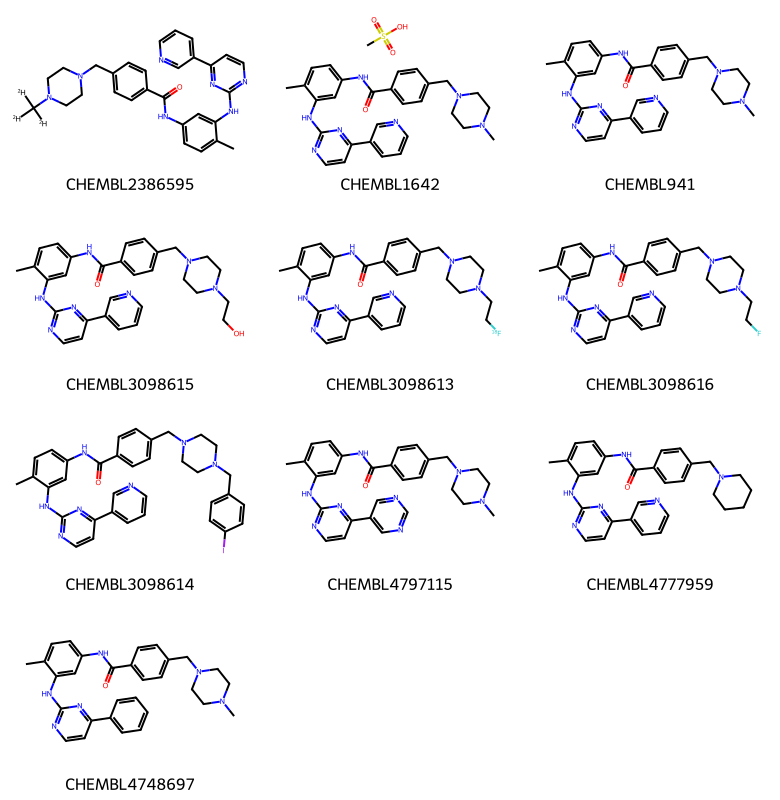

In [17]:
raw_mols = [Chem.MolFromSmiles(smi) for smi in df["smiles"]]
Draw.MolsToGridImage(
    [m for m in raw_mols if m is not None],
    legends=[i for i, m in zip(df["identifier"], raw_mols) if m is not None],
    molsPerRow=3, subImgSize=(260, 200),
)

## 2. Parse & sanitize

`Chem.MolFromSmiles` parses **and sanitizes** in one step: it computes valences, perceives
aromaticity, Kekulizes, and assigns stereochemistry. If the input is chemically nonsensical it returns
`None` rather than raising — so **always check for `None`**.

In [18]:
records = []
for identifier, smi in zip(df["identifier"], df["smiles"]):
    mol = Chem.MolFromSmiles(smi)            # None if parsing/sanitization fails
    if mol is None:
        print(f"  dropped {identifier}: could not parse/sanitize {smi!r}")
        continue
    records.append({"identifier": identifier, "mol": mol})

print(f"{len(records)} molecules parsed & sanitized")

10 molecules parsed & sanitized


## 3. Standardize

Database structures arrive as salts, mixtures, and arbitrary charge/tautomer states. We
**standardize** so chemically identical molecules end up identical, using `rdMolStandardize`:

- **`LargestFragmentChooser`** — drop counter-ions and solvents, keep the parent fragment.
- **`Cleanup`** — normalize functional groups, fix radicals, remove explicit Hs.
- **`Uncharger`** — neutralize formal charges where chemically reasonable.

In [19]:
largest_fragment = rdMolStandardize.LargestFragmentChooser()
uncharger = rdMolStandardize.Uncharger()

for r in records:
    parent  = largest_fragment.choose(r["mol"])   # strip salts / solvents
    cleaned = rdMolStandardize.Cleanup(parent)     # normalize
    neutral = uncharger.uncharge(cleaned)          # neutralize where reasonable
    r["std_mol"] = neutral
    r["std_smiles"] = Chem.MolToSmiles(neutral)

pd.DataFrame(
    [{"identifier": r["identifier"],
      "input_smiles": Chem.MolToSmiles(r["mol"]),
      "standardized_smiles": r["std_smiles"]} for r in records]
)

,identifier,input_smiles,standardized_smiles
0,CHEMBL2386595,[2H]C([2H])([2H])N1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(...,[2H]C([2H])([2H])N1CCN(Cc2ccc(C(=O)Nc3ccc(C)c(...
1,CHEMBL1642,CS(=O)(=O)O.Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc...,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
2,CHEMBL941,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
3,CHEMBL3098615,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nc...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nc...
4,CHEMBL3098613,Cc1ccc(NC(=O)c2ccc(CN3CCN(CC[18F])CC3)cc2)cc1N...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CC[18F])CC3)cc2)cc1N...
5,CHEMBL3098616,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...
6,CHEMBL3098614,Cc1ccc(NC(=O)c2ccc(CN3CCN(Cc4ccc(I)cc4)CC3)cc2...,Cc1ccc(NC(=O)c2ccc(CN3CCN(Cc4ccc(I)cc4)CC3)cc2...
7,CHEMBL4797115,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...
8,CHEMBL4777959,Cc1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)cc1Nc1nccc(-c...,Cc1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)cc1Nc1nccc(-c...
9,CHEMBL4748697,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...,Cc1ccc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)cc1Nc1nccc...


## 4. Remove isotope-only duplicates

We collapse each isotope-only duplicate group to one representative.

In [20]:
def isotope_stripped_smiles(mol):
    """Canonical SMILES with all isotope labels cleared - identifies isotopologues."""
    stripped = Chem.Mol(mol)
    for atom in stripped.GetAtoms():
        atom.SetIsotope(0)
    return Chem.MolToSmiles(stripped)

groups = {}
for r in records:
    groups.setdefault(isotope_stripped_smiles(r["std_mol"]), []).append(r)

deduped = []
for key, group in groups.items():
    if len(group) == 1:
        deduped.append(group[0])
        continue
    # Prefer the group member with no isotope labels at all; otherwise keep the first.
    representative = next((r for r in group if r["std_smiles"] == key), group[0])
    deduped.append(representative)
    for r in group:
        if r is not representative:
            print(f"  {r['identifier']}: isotopologue of {representative['identifier']} "
                  f"(identical once isotope labels are removed) -> dropped as redundant for docking")

print(f"\n{len(records)} standardized -> {len(deduped)} after isotope-dedup")
records = deduped

  CHEMBL941: isotopologue of CHEMBL1642 (identical once isotope labels are removed) -> dropped as redundant for docking
  CHEMBL3098613: isotopologue of CHEMBL3098616 (identical once isotope labels are removed) -> dropped as redundant for docking

10 standardized -> 8 after isotope-dedup


## 5. Fingerprint similarity in RDKit

The same 2D similarity ChEMBL used, reproduced locally with the **modern**
`rdFingerprintGenerator` API — a Morgan fingerprint of radius 2 (≈ ECFP4). We rank each standardized
analog by Tanimoto similarity to Imatinib.

In [21]:
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
reference_fp = morgan_gen.GetFingerprint(Chem.MolFromSmiles(REFERENCE_SMILES))
fps = [morgan_gen.GetFingerprint(r["std_mol"]) for r in records]
similarities = DataStructs.BulkTanimotoSimilarity(reference_fp, fps)

pd.DataFrame(
    {"identifier": [r["identifier"] for r in records],
     "Tanimoto_to_imatinib": [round(s, 3) for s in similarities]}
).sort_values("Tanimoto_to_imatinib", ascending=False).reset_index(drop=True)

,identifier,Tanimoto_to_imatinib
0,CHEMBL1642,1.000
1,CHEMBL2386595,0.900
2,CHEMBL3098615,0.886
3,CHEMBL3098616,0.873
4,CHEMBL3098614,0.871
5,CHEMBL4797115,0.870
6,CHEMBL4777959,0.870
7,CHEMBL4748697,0.868


## 6. Protonation at physiological pH

A molecule's **protonation (ionization) state** depends on the **pKa** of its ionizable groups and the
**pH** of the environment (~7.4 in blood). It sets the net **charge** and the **H-bond donor/acceptor**
pattern — both of which change docking scores and poses. So we must fix it *before* docking.

**RDKit alone cannot do this.** `Chem.AddHs` only adds hydrogens consistent with the structure but it has **no pKa model** and will not deprotonate an acid or protonate a base for a target
pH.

In [22]:
demo = Chem.MolFromSmiles("OC(=O)CCN")   # beta-alanine: carboxylic acid (pKa~4) + amine (pKa~10)
print("As drawn (neutral):  ", Chem.MolToSmiles(demo))
print("After RDKit AddHs:   ", Chem.MolToSmiles(Chem.AddHs(demo)),
      " <- still neutral; RDKit ionized nothing")
print()
print("At pH 7.4 the dominant species is the zwitterion:  [O-]C(=O)CC[NH3+]")
print("Deciding that needs a pKa-aware tool -> Gypsum-DL / Dimorphite-DL (section 9).")

As drawn (neutral):   NCCC(=O)O
After RDKit AddHs:    [H]OC(=O)C([H])([H])C([H])([H])N([H])[H]  <- still neutral; RDKit ionized nothing

At pH 7.4 the dominant species is the zwitterion:  [O-]C(=O)CC[NH3+]
Deciding that needs a pKa-aware tool -> Gypsum-DL / Dimorphite-DL (section 9).


## 7. Production prep with Gypsum-DL

For the real library we hand off to **[Gypsum-DL](https://durrantlab.pitt.edu/gypsum-dl/)**, which
automates the generation of different alternate ionization, tautomeric, chiral, isomeric, and ring-conformational states for each molecule. It uses ...

- **Protonation** across a pH window with **[Dimorphite-DL](https://durrantlab.pitt.edu/dimorphite-dl/)**
  (pKa-based enumeration of ionization states).
- **Tautomer, stereoisomer, and ring-conformation** enumeration.
- **3D embedding + force-field optimization** (RDKit under the hood).

We write the standardized molecules to a `.smi` file (`SMILES<TAB>identifier`) and run Gypsum-DL over
a physiological pH window (7.0–8.0). We cap at **one variant per compound** to keep the demo library
small — raise `--max_variants_per_compound` to enumerate multiple protonation/tautomer states (each
becomes a separate molecule to dock).

The pH window matters a lot: too wide and Dimorphite-DL starts deprotonating weakly-acidic groups it
shouldn't (see the QC step next); too narrow and it can over-protonate. 7.0–8.0 is a sensible default
centered near blood pH (~7.4).

The identifier becomes the molecule's **SDF title**, which is load-bearing: `vs_autodock` uses the
alphanumeric title to name each ligand's output folder — so we strip identifiers to alphanumerics now
to match.

> **Note.** For an `.sdf` library, `vs_autodock` does **not** re-protonate or regenerate 3D — it trusts
> the hydrogens and coordinates in the file. This step is where they are decided.

In [31]:
def alnum(s):                       # match vs_autodock, which keeps only alphanumerics of the title
    return "".join(c for c in s if c.isalnum())

smi_path = os.path.join(WORK_DIR, "standardized_ligands.smi")
with open(smi_path, "w") as fh:
    for r in records:
        fh.write(f"{r['std_smiles']}\t{alnum(r['identifier'])}\n")
print("Wrote", smi_path)

gypsum_out = os.path.join(WORK_DIR, "gypsum_out")
shutil.rmtree(gypsum_out, ignore_errors=True)
os.makedirs(gypsum_out, exist_ok=True)

# Resolve the gypsum-dl console script next to this kernel's Python (robust to PATH)
import sys
gypsum_bin = os.path.join(os.path.dirname(sys.executable), "gypsum-dl")
if not os.path.exists(gypsum_bin):
    gypsum_bin = shutil.which("gypsum-dl") or "gypsum-dl"

cmd = [
    gypsum_bin,
    "--source", smi_path,
    "--output_folder", gypsum_out,
    "--min_ph", str(MIN_PH), "--max_ph", str(MAX_PH), "--pka_precision", str(PKA_PRECISION),
    "--max_variants_per_compound", str(MAX_VARIANTS),
    "--job_manager", "multiprocessing", "--num_processors", "4",
]
print("Running:", " ".join(cmd), "\n")
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stdout[-1500:])
if res.returncode != 0:
    print("STDERR:\n", res.stderr[-1500:])
    raise RuntimeError("Gypsum-DL failed")

Wrote ligand_prep_out/standardized_ligands.smi
Running: /home/pnavarro/.conda/envs/biobb_vs_ligprep/bin/gypsum-dl --source ligand_prep_out/standardized_ligands.smi --output_folder ligand_prep_out/gypsum_out --min_ph 7.0 --max_ph 8.0 --pka_precision 0.5 --max_variants_per_compound 3 --job_manager multiprocessing --num_processors 4 

C(\O)c2ccc(CN3CC[NH+](C)CC3)cc2)cc1Nc1nccc(-
                c2cncnc2)n1
        MolContainer #6 (CHEMBL4777959)
            Mol #0:
                Cc1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)cc1/N=c1\nc(-c2cccnc2)cc[nH]1
            Mol #1:
                Cc1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)cc1/N=c1\nc(-c2cccnc2)cc[nH]1
            Mol #2:
                Cc1ccc(NC(=O)c2ccc(CN3CCCCC3)cc2)cc1/N=c1\nc(-c2cccnc2)cc[nH]1
        MolContainer #7 (CHEMBL4748697)
            Mol #0: Cc1ccc(NC(=O)c2ccc(C[NH+]3CC[NH+](C)CC3)cc2)cc1/N=c1\nc(-
                c2ccccc2)cc[nH]1
            Mol #1: Cc1ccc(NC(=O)c2ccc(C[NH+]3CC[NH+](C)CC3)cc2)cc1/N=c1\nc(-
                c2ccccc2)cc

## 8. Load and finalize

Gypsum-DL writes everything to a single `gypsum_dl_success.sdf`. Its **first record is an empty
placeholder** holding the run parameters, so we skip any molecule with zero atoms. We keep the 3D
coordinates and explicit hydrogens Gypsum produced (`removeHs=False`) and set each title to the
alphanumeric identifier.

In [32]:
success_sdf = os.path.join(gypsum_out, "gypsum_dl_success.sdf")
supplier = Chem.SDMolSupplier(success_sdf, removeHs=False)   # keep protonation!

prepared = []
for mol in supplier:
    if mol is None or mol.GetNumAtoms() == 0:                # skip Gypsum's params placeholder
        continue
    title = alnum(mol.GetProp("_Name")) if mol.HasProp("_Name") else f"ligand{len(prepared)}"
    mol.SetProp("_Name", title)
    has_3d = mol.GetNumConformers() > 0 and mol.GetConformer().Is3D()
    prepared.append(mol)
    print(f"  {title:24s} atoms={mol.GetNumAtoms():3d}  3D={has_3d}")

print(f"\n{len(prepared)} prepared 3D molecules")
assert prepared, "No molecules survived Gypsum-DL preparation."

  CHEMBL2386595            atoms= 68  3D=True
  CHEMBL2386595            atoms= 68  3D=True
  CHEMBL2386595            atoms= 68  3D=True
  CHEMBL1642               atoms= 69  3D=True
  CHEMBL1642               atoms= 69  3D=True
  CHEMBL1642               atoms= 68  3D=True
  CHEMBL3098615            atoms= 72  3D=True
  CHEMBL3098615            atoms= 74  3D=True
  CHEMBL3098615            atoms= 72  3D=True
  CHEMBL3098616            atoms= 72  3D=True
  CHEMBL3098616            atoms= 72  3D=True
  CHEMBL3098616            atoms= 72  3D=True
  CHEMBL3098614            atoms= 80  3D=True
  CHEMBL3098614            atoms= 80  3D=True
  CHEMBL3098614            atoms= 80  3D=True
  CHEMBL4797115            atoms= 67  3D=True
  CHEMBL4797115            atoms= 67  3D=True
  CHEMBL4797115            atoms= 68  3D=True
  CHEMBL4777959            atoms= 66  3D=True
  CHEMBL4777959            atoms= 66  3D=True
  CHEMBL4777959            atoms= 66  3D=True
  CHEMBL4748697            atoms= 

### Sanity-check the protonation

Automated protonation is approximate — **always inspect the output**. Below we report each molecule's
net formal charge and flag a specific, documented artifact: a **deprotonated amide** `[N-]–C(=O)`.
Dimorphite-DL models any amide bearing an **N–H** as weakly acidic, so secondary anilides (like ours)
can be *wrongly* deprotonated in a wide pH window — we chose 7.0–8.0 partly to avoid this. Things to
watch for in general:

- **Spurious amide anions** — should all read `False` here.
- **Over-protonation.** The N-methylpiperazine has two basic nitrogens; Dimorphite-DL assigns their
  pKa values independently and ignores the charge–charge repulsion that lowers the second, so a narrow
  window right at 7.4 can protonate *both* (net +2) when the +1 monocation actually dominates.
- **Window sensitivity.** Near-identical analogs can land on different states (neutral vs +1) simply
  because a pKa sits at the window edge. When in doubt, **enumerate** states
  (`--max_variants_per_compound > 1`) rather than commit to a single guess.

In [33]:
amide_anion = Chem.MolFromSmarts("[NX2-][CX3]=[OX1]")   # deprotonated amide N (Dimorphite N-H edge case)

qc = []
for m in prepared:
    qc.append({
        "identifier": m.GetProp("_Name"),
        "net_charge": sum(a.GetFormalCharge() for a in m.GetAtoms()),
        "spurious_amide_anion": m.HasSubstructMatch(amide_anion),
    })
qc_df = pd.DataFrame(qc).set_index("identifier")
if qc_df["spurious_amide_anion"].any():
    print("WARNING: deprotonated amide detected - narrow the pH window or neutralize before docking.")
qc_df

,net_charge,spurious_amide_anion
identifier,,
CHEMBL2386595,0,False
CHEMBL2386595,0,False
CHEMBL2386595,0,False
CHEMBL1642,1,False
CHEMBL1642,1,False
CHEMBL1642,0,False
CHEMBL3098615,0,False
CHEMBL3098615,2,False
CHEMBL3098615,0,False


## 9. Write the docking-ready SDF

Write the prepared molecules to `data/ligands/`, then read them back to confirm the file is valid:
every record has a 3D conformer, explicit hydrogens, and an alphanumeric title.

In [34]:
os.makedirs(os.path.dirname(OUTPUT_SDF), exist_ok=True)
writer = Chem.SDWriter(OUTPUT_SDF)
for mol in prepared:
    writer.write(mol)
writer.close()
print(f"Wrote {len(prepared)} molecules to {OUTPUT_SDF}")

# --- Verify ---
check = [m for m in Chem.SDMolSupplier(OUTPUT_SDF, removeHs=False) if m is not None]
assert len(check) == len(prepared), "record count mismatch"
for m in check:
    assert m.GetNumConformers() > 0 and m.GetConformer().Is3D(), f"{m.GetProp('_Name')}: no 3D coords"
    assert any(a.GetSymbol() == "H" for a in m.GetAtoms()), f"{m.GetProp('_Name')}: no explicit Hs"
    assert m.GetProp("_Name").isalnum(), f"{m.GetProp('_Name')}: non-alphanumeric title"
print("Verified:", len(check), "records, all 3D with explicit Hs and alphanumeric titles.")

Wrote 24 molecules to data/ligands/imatinib_analogs_prepared.sdf
Verified: 24 records, all 3D with explicit Hs and alphanumeric titles.


## 10. Wrap-up

You went from a single reference drug to a small, **protonated, 3D, docking-ready SDF**:

```
ChEMBL  ->  sanitize  ->  standardize  ->  (QC)  ->  Gypsum-DL (protonate + 3D)  ->  SDF
```

Feed it straight into the virtual-screening tutorial by pointing `--ligand_lib` at the file:

```bash
vs_autodock --ligand_lib data/ligands/imatinib_analogs_prepared.sdf ...
```

or set `ligand_lib = "data/ligands/imatinib_analogs_prepared.sdf"` in
[`notebook_tutorial.ipynb`](notebook_tutorial.ipynb). Remember: for `.sdf` input the workflow trusts
these coordinates and hydrogens **as-is** — no re-protonation downstream.

### Limitations recap
- **2D similarity** seeds structurally-related molecules, not verified binders.
- **Standardization** commits to one canonical tautomer/parent fragment.
- **Protonation** uses empirical pKa and keeps only the dominant microstate(s) in the pH window.
- **One 3D conformer** per variant; the bioactive conformer may differ, and force-field ≠ quantum
  energies. Docking re-samples torsions but not ring/stereo inversions.

### Next steps
- Enumerate more states: raise `--max_variants_per_compound` (protonation/tautomer/stereo variants).
- Widen or narrow the pH window (`--min_ph`/`--max_ph`) for your assay conditions.
- Swap the seed SMILES / similarity threshold to build a different focused library.

### Further reading
- [RDKit docs](https://www.rdkit.org/docs/) · [RDKit Cookbook](https://www.rdkit.org/docs/Cookbook.html)
- Ropp *et al.* **Gypsum-DL** (*J. Cheminform.* 2019) · **Dimorphite-DL** (*J. Cheminform.* 2019)